ПРАКТИКА 10. НЕПЕРЕРВНІ РОЗПОДІЛИ В SCIPY.STATS

Варіант: 4
Місто: Харків
Липнева температура: 22 °C

Згенерована вибірка:
[22.12640427 23.24987833 19.51022767 23.73399627 20.9542462  18.03855691
 20.38073308 23.49643793 22.83062508 19.13130842 23.54667422 21.78003268
 23.06268099 22.83063286 19.10795935 22.87749288 20.48278179 25.86744832
 23.80835402 22.11533892 19.54252087 22.13608185 22.39973234 18.9776296
 27.55840054 22.98573804 26.23089429 19.21796962 26.08936885 18.59758602]

Параметри нормального розподілу:
mean = 22.088924407492264
std  = 2.4235613712693516


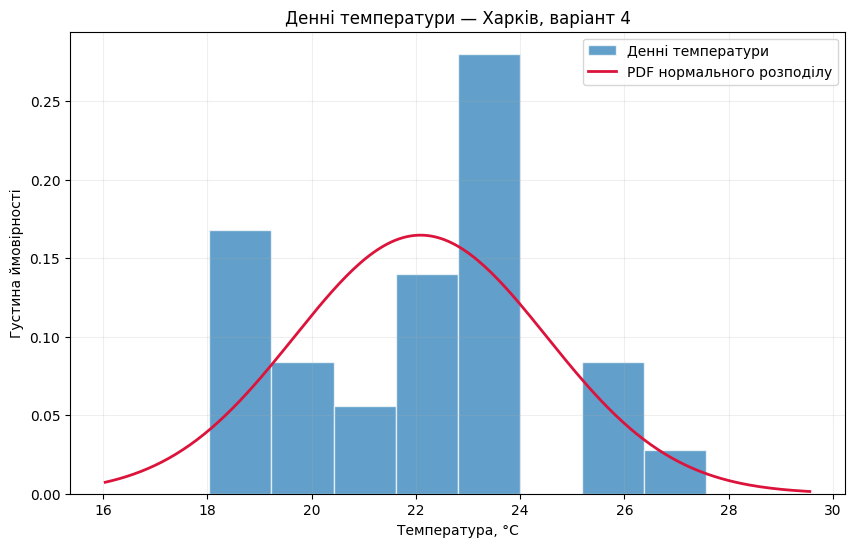


Завдання 4:
Інтервал: 19.665363036222914 до 24.512485778761615 °C
Ймовірність: 0.6826894921370856
У відсотках: 68.26894921370857 %

Завдання 5:
95-й процентиль: 26.07532811916414 °C


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ==========================================
# Практика 10
# Варіант 4 — Харків
# ==========================================

city = "Харків"
july_temp = 22

# Завдання 1. Генерація вибірки
np.random.seed(4)

daily_temps = np.random.normal(
    loc=july_temp,
    scale=2.5,
    size=30
)

print("=" * 50)
print("ПРАКТИКА 10. НЕПЕРЕРВНІ РОЗПОДІЛИ В SCIPY.STATS")
print("=" * 50)

print("\nВаріант:", 4)
print("Місто:", city)
print("Липнева температура:", july_temp, "°C")

print("\nЗгенерована вибірка:")
print(daily_temps)

# Завдання 2. Параметри розподілу
mean = daily_temps.mean()
std = daily_temps.std()

dist = stats.norm(loc=mean, scale=std)

print("\nПараметри нормального розподілу:")
print("mean =", mean)
print("std  =", std)

# Завдання 3. Гістограма + PDF
x = np.linspace(
    daily_temps.min() - 2,
    daily_temps.max() + 2,
    200
)

plt.figure(figsize=(10, 6))

plt.hist(
    daily_temps,
    bins=8,
    density=True,
    edgecolor="white",
    alpha=0.7,
    label="Денні температури"
)

plt.plot(
    x,
    dist.pdf(x),
    color="crimson",
    linewidth=2,
    label="PDF нормального розподілу"
)

plt.xlabel("Температура, °C")
plt.ylabel("Густина ймовірності")
plt.title("Денні температури — Харків, варіант 4")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Завдання 4. Ймовірність у межах ±1 стандартного відхилення
lower = mean - std
upper = mean + std

probability = dist.cdf(upper) - dist.cdf(lower)

print("\nЗавдання 4:")
print("Інтервал:", lower, "до", upper, "°C")
print("Ймовірність:", probability)
print("У відсотках:", probability * 100, "%")

# Завдання 5. 95-й процентиль
percentile_95 = dist.ppf(0.95)

print("\nЗавдання 5:")
print("95-й процентиль:", percentile_95, "°C")


Питання 1. Різниця між .pdf(x) і .cdf(x)
.pdf(x) повертає значення густини ймовірності нормального розподілу в точці x. Вона показує, наскільки щільно розподілені значення біля певної точки.

.cdf(x) повертає накопичену ймовірність — ймовірність того, що випадкова величина буде меншою або дорівнюватиме x.

Отже, .pdf() відповідає на питання «яка густина розподілу біля цього значення?», а .cdf() — «яка частина значень знаходиться зліва від цього значення?».

Питання 2. Чому .pdf(x) може бути більшою за 1?
Значення .pdf(x) може бути більшим за 1, тому що PDF — це густина ймовірності, а не сама ймовірність. Ймовірність для окремої точки неперервного розподілу фактично дорівнює нулю. Ймовірність отримують як площу під PDF на певному інтервалі.

Тому значення густини може бути більшим за 1. Важливо, щоб загальна площа під кривою PDF дорівнювала 1. Це не суперечить тому, що сама ймовірність не може бути більшою за 1.

Питання 3. Чому .ppf() є оберненою до .cdf()?
.cdf(x) приймає на вході значення x і повертає накопичену ймовірність p.

.ppf(p) робить навпаки: приймає ймовірність p і повертає значення x, для якого CDF(x) = p.

Наприклад, dist.cdf(x) може показати, що 95% значень лежать нижче певної температури. Тоді dist.ppf(0.95) безпосередньо знайде цю температуру.